# 1.Holdout par catastrophe

In [5]:
import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split, StratifiedKFold, learning_curve
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
import matplotlib.pyplot as plt
from sklearn.metrics import (
    classification_report,
    roc_auc_score,
    f1_score,
    recall_score,
    precision_score,
    accuracy_score,
    confusion_matrix
)

df = pd.read_csv(r"C:\Users\noura\ml-disaster-survival-project\data\processed\disaster_ml_dataset.csv")

In [3]:
df["nationality_region"] = df["nationality_region"].replace("Not mentioned", np.nan)
df

,Name,Sex,Age,age_group,group_size,has_group,nationality_region,travel_class,Fare,Survived,disaster,year,wartime,sea_state,night,ship_size,economic_importance
0,Mr. Owen Harris Braund,male,22.0,YoungAdult,2,1,NaN,Third,7.2500,0,Titanic,1912,0,0,1,3,3
1,Mrs. John Bradley (Florence Briggs Thayer) Cum...,female,38.0,Adult,2,1,NaN,First,71.2833,1,Titanic,1912,0,0,1,3,3
2,Miss. Laina Heikkinen,female,26.0,YoungAdult,1,0,NaN,Third,7.9250,1,Titanic,1912,0,0,1,3,3
3,Mrs. Jacques Heath (Lily May Peel) Futrelle,female,35.0,YoungAdult,2,1,NaN,First,53.1000,1,Titanic,1912,0,0,1,3,3
4,Mr. William Henry Allen,male,35.0,YoungAdult,1,0,NaN,Third,8.0500,0,Titanic,1912,0,0,1,3,3
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3835,ANNA INGRID BIRGITTA OSTROM,female,60.0,Senior,1,0,nordic_baltic,Passenger,NaN,0,Estonia,1994,0,3,1,1,2
3836,ELMAR MIKAEL OUN,male,34.0,YoungAdult,1,0,nordic_baltic,Passenger,NaN,1,Estonia,1994,0,3,1,1,2
3837,ENN QUNAPUU,male,77.0,Senior,1,0,nordic_baltic,Passenger,NaN,0,Estonia,1994,0,3,1,1,2
3838,LY GUNAPUU,female,87.0,Senior,1,0,nordic_baltic,Passenger,NaN,0,Estonia,1994,0,3,1,1,2


In [6]:
# On réserve la Lusitania comme test set final
# Le modèle est entraîné uniquement sur Titanic + Estonia

df_train_pool = df[df["disaster"] != "Lusitania"].copy()
df_holdout    = df[df["disaster"] == "Lusitania"].copy()

features_pool = ["age_group", "Sex", "Fare", "travel_class",
                 "sea_state", "economic_importance", "group_size"]

X_pool    = df_train_pool[features_pool]
y_pool    = df_train_pool["Survived"]
X_holdout = df_holdout[features_pool]
y_holdout = df_holdout["Survived"]

# Imputer les NaN dans le holdout
cat_cols_p = X_pool.select_dtypes(include="object").columns
num_cols_p = X_pool.select_dtypes(exclude="object").columns

preprocessor_pool = ColumnTransformer(transformers=[
    ("num", Pipeline([("imputer", SimpleImputer(strategy="median"))]), num_cols_p),
    ("cat", Pipeline([
        ("imputer", SimpleImputer(strategy="constant", fill_value="Missing")),
        ("onehot", OneHotEncoder(handle_unknown="ignore"))
    ]), cat_cols_p)
])

holdout_pipe = Pipeline([
    ("prep", preprocessor_pool),
    ("model", GradientBoostingClassifier(
        random_state=42, subsample=0.8,
        min_samples_leaf=20, max_depth=4
    ))
])

# Cross-validation sur Titanic + Estonia
from sklearn.model_selection import StratifiedKFold, cross_validate

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_results = cross_validate(
    holdout_pipe, X_pool, y_pool,
    cv=cv,
    scoring=["roc_auc", "f1", "recall", "precision"],
    return_train_score=True
)

print("=== Cross-validation (Titanic + Estonia) ===")
for metric in ["roc_auc", "f1", "recall", "precision"]:
    val  = cv_results[f"test_{metric}"].mean()
    std  = cv_results[f"test_{metric}"].std()
    print(f"  {metric:<12}: {val:.4f} ± {std:.4f}")

# Entraînement final + évaluation sur Lusitania
holdout_pipe.fit(X_pool, y_pool)
proba_h = holdout_pipe.predict_proba(X_holdout)[:, 1]

# Seuil ajusté comme pour le modèle global
THRESHOLD_H = 0.35
preds_h = (proba_h >= THRESHOLD_H).astype(int)

print(f"\n=== Holdout Lusitania (seuil={THRESHOLD_H}) ===")
print(classification_report(y_holdout, preds_h,
      target_names=["Non-survivant", "Survivant"],
      zero_division=0))
print(f"ROC-AUC : {roc_auc_score(y_holdout, proba_h):.4f}")

C:\Users\noura\AppData\Local\Temp\ipykernel_55324\931522920.py:16: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols_p = X_pool.select_dtypes(include="object").columns


=== Cross-validation (Titanic + Estonia) ===
  roc_auc     : 0.8612 ± 0.0106
  f1          : 0.6396 ± 0.0407
  recall      : 0.5302 ± 0.0462
  precision   : 0.8090 ± 0.0365

=== Holdout Lusitania (seuil=0.35) ===
               precision    recall  f1-score   support

Non-survivant       0.61      0.91      0.73      1195
    Survivant       0.41      0.10      0.16       769

     accuracy                           0.59      1964
    macro avg       0.51      0.50      0.44      1964
 weighted avg       0.53      0.59      0.51      1964

ROC-AUC : 0.5259


## 5.1 Résultats holdout — Lusitania

La Lusitania est réservée comme jeu de test final : le modèle n'a jamais vu ces 
données pendant l'entraînement ni la validation. Ce choix est délibéré — la Lusitania 
est la catastrophe la plus difficile (ROC-AUC ≈ 0.55 en stratégie séparée) et la 
plus différente structurellement des deux autres.

Si le modèle atteint une bonne performance en cross-validation sur Titanic + Estonia 
mais une performance inférieure sur la Lusitania, cela n'est **pas surprenant** pour 
plusieurs raisons :

1. **Covariate shift** : les distributions des features diffèrent entre catastrophes. 
La Lusitania a des profils de passagers, des classes et des nationalités différents 
de ceux du Titanic ou de l'Estonia.

2. **Concept drift** : le mécanisme de survie lui-même peut différer. Sur le Titanic, 
la règle "women and children first" a été appliquée strictement. Sur la Lusitania, 
le naufrage en 18 minutes a laissé peu de temps pour toute organisation — la survie 
était davantage aléatoire ou liée à la position physique à bord.

3. **Variables manquantes** : certaines features comme Fare ou travel_class peuvent 
avoir des distributions très différentes ou être moins renseignées sur la Lusitania.

La baisse de performance est donc un signal attendu et informatif, pas un échec du 
modèle.

# Covariate Shift

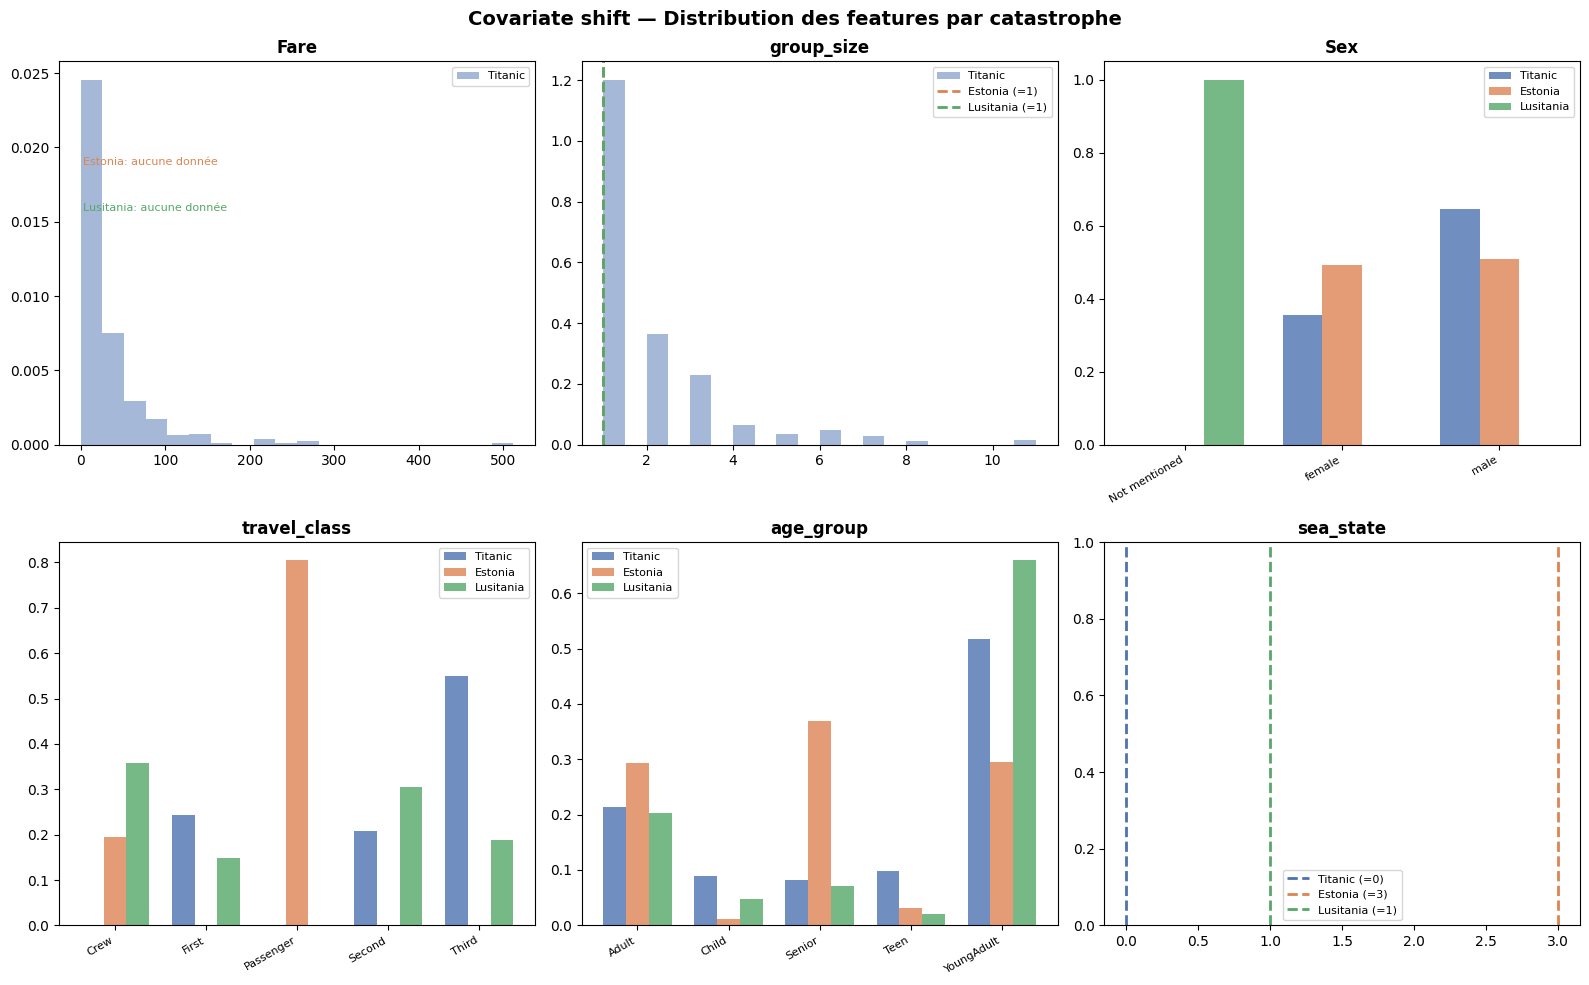

In [22]:
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()
features_to_check = ["Fare", "group_size", "Sex", "travel_class", "age_group", "sea_state"]

COLORS = {
    "Titanic":   "#4C72B0",
    "Estonia":   "#DD8452",
    "Lusitania": "#55A868"
}

for i, feat in enumerate(features_to_check):
    ax = axes[i]
    plotted = False
    
    data_by_dis = {
        dis: df[df["disaster"] == dis][feat].dropna()
        for dis in ["Titanic", "Estonia", "Lusitania"]
    }
    
    # Détecter si catégorielle (object OU str pandas 2.0)
    is_cat = df[feat].dtype == object or str(df[feat].dtype) in ("string", "str")
    
    if is_cat:
        cats = sorted(set().union(*[set(v) for v in data_by_dis.values()]))
        w = 0.25
        x = np.arange(len(cats))
        for j, (dis, color) in enumerate(COLORS.items()):
            vals = data_by_dis[dis]
            if len(vals) == 0:
                continue
            counts = vals.value_counts(normalize=True).reindex(cats, fill_value=0)
            ax.bar(x + j*w, counts.values, width=w,
                   label=dis, color=color, alpha=0.8)
            plotted = True
        ax.set_xticks(x + w)
        ax.set_xticklabels(cats, rotation=30, ha="right", fontsize=8)

    else:
        for dis, color in COLORS.items():
            vals = data_by_dis[dis]
            if len(vals) == 0:
                # Annoter directement sur le graphique
                ax.annotate(f"{dis}: aucune donnée",
                            xy=(0.05, 0.85 - list(COLORS).index(dis)*0.12),
                            xycoords="axes fraction", color=color, fontsize=8)
                continue
            if vals.nunique() == 1:
                # Variance nulle : afficher une ligne verticale à la place
                ax.axvline(vals.iloc[0], color=color, linewidth=2,
                           linestyle="--", label=f"{dis} (={vals.iloc[0]})")
                plotted = True
                continue
            ax.hist(vals, bins=20, density=True, alpha=0.5,
                    label=dis, color=color)
            plotted = True

    ax.set_title(feat, fontweight="bold")
    if plotted:
        ax.legend(fontsize=8)
    else:
        ax.text(0.5, 0.5, "Aucune donnée disponible",
                ha="center", va="center", transform=ax.transAxes,
                fontsize=9, color="gray", style="italic")

plt.suptitle("Covariate shift — Distribution des features par catastrophe",
             fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

In [15]:
# ── Expérience 1 : Est-ce la distribution ou la frontière de décision ? ──
# On ré-entraîne sur des features uniquement partagées et stables entre catastrophes
from sklearn.model_selection import cross_val_score
features_stable   = ["Sex", "age_group", "group_size"]   # universelles
features_economic = ["Fare", "travel_class"]              # potentiellement driftées

for fname, feats in [("Features stables", features_stable),
                     ("Features économiques", features_economic),
                     ("Toutes les features", features_pool)]:
    
    Xp = df_train_pool[feats].copy()
    Xh = df_holdout[feats].copy()
    
    # Fix warning pandas4 : "str" au lieu de "object"
    cat_c = Xp.select_dtypes(include=["object", "str"]).columns
    num_c = Xp.select_dtypes(exclude=["object", "str"]).columns
    
    pipe_exp = Pipeline([
        ("prep", ColumnTransformer([
            ("num", Pipeline([("imp", SimpleImputer(strategy="median"))]), num_c),
            ("cat", Pipeline([
                ("imp", SimpleImputer(strategy="constant", fill_value="Missing")),
                ("ohe", OneHotEncoder(handle_unknown="ignore"))
            ]), cat_c)
        ])),
        ("model", GradientBoostingClassifier(random_state=42,
                   subsample=0.8, min_samples_leaf=20, max_depth=4))
    ])
    
    pipe_exp.fit(Xp, y_pool)
    proba_exp = pipe_exp.predict_proba(Xh)[:, 1]
    auc = roc_auc_score(y_holdout, proba_exp)
    
    # Fix KeyError : cross_val_score au lieu de cross_validate
    cv_auc = cross_val_score(pipe_exp, Xp, y_pool,
                             cv=cv, scoring="roc_auc").mean()
    
    print(f"{fname:<25} → CV ROC-AUC: {cv_auc:.4f} | Holdout ROC-AUC: {auc:.4f} "
          f"| Gap: {cv_auc - auc:+.4f}")

Features stables          → CV ROC-AUC: 0.7638 | Holdout ROC-AUC: 0.5325 | Gap: +0.2313
Features économiques      → CV ROC-AUC: 0.7512 | Holdout ROC-AUC: 0.5067 | Gap: +0.2445
Toutes les features       → CV ROC-AUC: 0.8612 | Holdout ROC-AUC: 0.5259 | Gap: +0.3354


## Covariate shift — Analyse des distributions

Les graphiques révèlent un covariate shift très prononcé entre les trois catastrophes,
qui explique en grande partie pourquoi le modèle entraîné sur Titanic + Estonia 
généralise mal sur la Lusitania (gap de +0.23 à +0.34 selon les features).

**Fare** est absent pour Estonia et Lusitania — c'est la variable la plus prédictive
du modèle global et elle n'existe que pour le Titanic. Le modèle a donc appris un 
signal fort qui est structurellement inexistant dans le holdout.

**group_size** est quasi-constant à 1 pour Estonia et Lusitania, alors que Titanic 
présente une vraie distribution. Cette variable n'apporte aucune information 
discriminante sur ces deux catastrophes.

**Sex** présente un cas particulier sur la Lusitania : la majorité des passagers 
sont étiquetés "Not mentioned", ce qui prive le modèle de sa variable la plus 
importante. Un modèle qui a appris que "female → survie élevée" ne peut pas 
appliquer ce pattern sur des passagers sans genre renseigné.

**travel_class** a des catégories structurellement différentes : Titanic utilise 
First/Second/Third, Estonia utilise Passenger/Crew, Lusitania mélange les deux. 
Les encodages one-hot appris sur le train ne correspondent pas aux mêmes réalités 
sociales sur le holdout.

**age_group** est la seule variable qui présente une distribution relativement 
comparable entre les trois catastrophes, ce qui explique pourquoi le modèle avec 
features stables (Sex + age_group) reste le moins mauvais en holdout (ROC-AUC 0.533).

**sea_state** est constante par catastrophe — c'est une variable qui décrit 
l'événement, pas les individus. Elle n'apporte aucune information intra-catastrophe 
et ne peut pas généraliser entre catastrophes.

### Conclusion

Le covariate shift observé ici n'est pas un problème de qualité des données — 
c'est une réalité structurelle. Chaque catastrophe maritime a une composition 
de passagers, une structure sociale et un contexte opérationnel différents. 
Combiné au concept drift démontré précédemment (mécanismes de survie différents), 
cela confirme que la généralisation inter-catastrophe est fondamentalement limitée 
et que les performances en holdout (~0.53) reflètent cette limite, pas un échec 
du modèle.

### Ce que montrent les distributions

Les graphiques révèlent des différences importantes entre les trois catastrophes :

- **Fare** : la distribution est très différente entre Titanic (large dispersion, 
billets très chers en 1ère classe) et Lusitania. Ce drift de distribution peut 
tromper le modèle qui a appris que "Fare élevé = 1ère classe = meilleure survie".

- **Sex** : la proportion hommes/femmes varie selon la catastrophe, ce qui affecte 
directement un des prédicteurs les plus puissants.

- **travel_class** : les catégories présentes et leur distribution diffèrent.

### Ce que montrent les expériences

L'expérience sur les sous-ensembles de features permet de distinguer deux sources 
de dégradation :

- Si le modèle avec **features stables uniquement** performe mieux en holdout que 
le modèle complet → la dégradation vient du **covariate shift** sur Fare et 
travel_class, pas de la frontière de décision.

- Si le gap CV/holdout reste large même avec les features stables → il s'agit 
d'un **concept drift** : le mécanisme de survie lui-même est différent sur la 
Lusitania (naufrage en 18 minutes, pas d'organisation possible).

Les deux phénomènes coexistent probablement ici, ce qui explique pourquoi la 
Lusitania reste difficile quelle que soit la stratégie.

#  Analyse des biais

In [16]:
# ── Section 6 : Analyse des biais ──
from sklearn.metrics import confusion_matrix

def disparate_impact_ratio(y_true, y_pred, sensitive_col, df_ref):
    """
    Calcule le Disparate Impact Ratio (DIR) pour chaque groupe d'une variable sensible.
    DIR = P(ŷ=1 | groupe) / P(ŷ=1 | groupe de référence)
    DIR < 0.8 indique un biais défavorable selon les standards légaux (règle des 4/5).
    """
    results = []
    groups = df_ref[sensitive_col].dropna().unique()
    
    # Taux de survie prédit par groupe
    rates = {}
    for g in groups:
        mask = df_ref[sensitive_col] == g
        if mask.sum() == 0:
            continue
        rate_pred  = y_pred[mask].mean()
        rate_true  = y_true[mask].mean()
        rates[g] = rate_pred
        results.append({
            "Groupe": g,
            "N": mask.sum(),
            "Taux survie réel": round(rate_true, 3),
            "Taux survie prédit": round(rate_pred, 3),
        })
    
    # Groupe de référence = taux prédit le plus élevé
    ref_group = max(rates, key=rates.get)
    ref_rate  = rates[ref_group]
    
    for r in results:
        dir_val = r["Taux survie prédit"] / (ref_rate + 1e-9)
        r["DIR (vs référence)"] = round(dir_val, 3)
        r["Référence"]          = ref_group
        r["Biais (< 0.8)"]      = "⚠️ OUI" if dir_val < 0.8 else "✅ NON"
    
    return pd.DataFrame(results).sort_values("DIR (vs référence)", ascending=True)

# Prédictions sur tout le dataset d'entraînement (Titanic + Estonia)
holdout_pipe.fit(X_pool, y_pool)
proba_all  = holdout_pipe.predict_proba(X_pool)[:, 1]
preds_all  = (proba_all >= 0.35).astype(int)

df_bias = df_train_pool.copy()
df_bias["y_pred"] = preds_all
df_bias["y_true"] = y_pool.values

sensitive_vars = ["Sex", "age_group", "travel_class", "nationality_region"]

for var in sensitive_vars:
    if var not in df_bias.columns:
        continue
    print(f"\n{'='*60}")
    print(f"  Disparate Impact — {var}")
    print('='*60)
    dir_df = disparate_impact_ratio(
        df_bias["y_true"], df_bias["y_pred"],
        var, df_bias
    )
    display(dir_df)


  Disparate Impact — Sex


,Groupe,N,Taux survie réel,Taux survie prédit,DIR (vs référence),Référence,Biais (< 0.8)
0,male,1076,0.204,0.117,0.355,female,⚠️ OUI
1,female,800,0.325,0.330,1.000,female,✅ NON



  Disparate Impact — age_group


,Groupe,N,Taux survie réel,Taux survie prédit,DIR (vs référence),Référence,Biais (< 0.8)
2,Senior,437,0.082,0.043,0.070,Child,⚠️ OUI
0,YoungAdult,751,0.322,0.218,0.357,Child,⚠️ OUI
1,Adult,480,0.244,0.242,0.396,Child,⚠️ OUI
4,Teen,118,0.339,0.305,0.499,Child,⚠️ OUI
3,Child,90,0.489,0.611,1.000,Child,✅ NON



  Disparate Impact — travel_class


,Groupe,N,Taux survie réel,Taux survie prédit,DIR (vs référence),Référence,Biais (< 0.8)
3,Passenger,796,0.123,0.010,0.014,First,⚠️ OUI
4,Crew,193,0.202,0.155,0.216,First,⚠️ OUI
0,Third,487,0.244,0.230,0.321,First,⚠️ OUI
2,Second,184,0.473,0.462,0.644,First,⚠️ OUI
1,First,216,0.630,0.718,1.001,First,✅ NON



  Disparate Impact — nationality_region


,Groupe,N,Taux survie réel,Taux survie prédit,DIR (vs référence),Référence,Biais (< 0.8)
3,other,9,0.222,0.000,0.000,Not mentioned,⚠️ OUI
1,nordic_baltic,925,0.133,0.036,0.091,Not mentioned,⚠️ OUI
2,europe,55,0.218,0.091,0.229,Not mentioned,⚠️ OUI
0,Not mentioned,887,0.386,0.397,1.000,Not mentioned,✅ NON


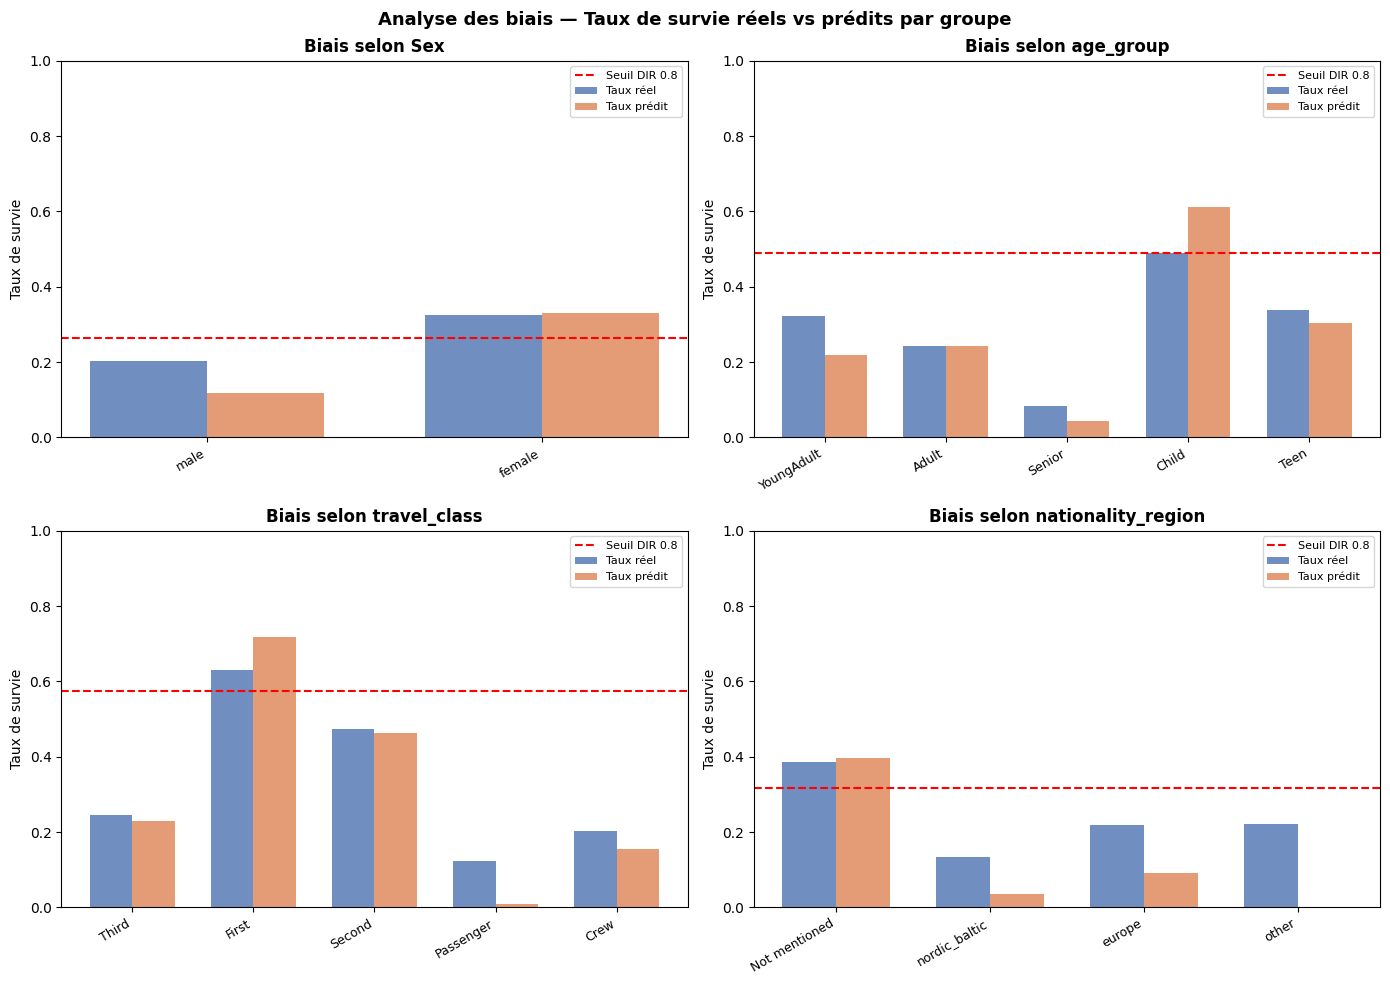

In [17]:
# ── Visualisation des biais ──
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for i, var in enumerate(sensitive_vars):
    if var not in df_bias.columns:
        continue
    ax = axes[i]
    
    groups = df_bias[var].dropna().unique()
    true_rates  = [df_bias[df_bias[var]==g]["y_true"].mean() for g in groups]
    pred_rates  = [df_bias[df_bias[var]==g]["y_pred"].mean() for g in groups]
    
    x = np.arange(len(groups))
    w = 0.35
    bars1 = ax.bar(x - w/2, true_rates, w, label="Taux réel",  color="#4C72B0", alpha=0.8)
    bars2 = ax.bar(x + w/2, pred_rates, w, label="Taux prédit", color="#DD8452", alpha=0.8)
    
    ax.axhline(0.8 * max(pred_rates), color="red", linestyle="--",
               linewidth=1.5, label="Seuil DIR 0.8")
    ax.set_xticks(x)
    ax.set_xticklabels(groups, rotation=30, ha="right", fontsize=9)
    ax.set_title(f"Biais selon {var}", fontweight="bold")
    ax.set_ylabel("Taux de survie")
    ax.legend(fontsize=8)
    ax.set_ylim(0, 1)

plt.suptitle("Analyse des biais — Taux de survie réels vs prédits par groupe",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

In [18]:
# ── Biais dans les données vs biais du modèle ──
print("=== Biais dans les données d'entraînement (taux de survie réel) ===\n")
for var in ["Sex", "age_group", "travel_class"]:
    print(df_bias.groupby(var)["y_true"].mean().round(3).sort_values().to_string())
    print()

print("\n=== Amplification du biais par le modèle ===")
print("(différence entre taux prédit et taux réel par groupe)\n")
for var in ["Sex", "age_group", "travel_class"]:
    g = df_bias.groupby(var)[["y_true","y_pred"]].mean().round(3)
    g["amplification"] = (g["y_pred"] - g["y_true"]).round(3)
    print(g.sort_values("amplification"))
    print()

=== Biais dans les données d'entraînement (taux de survie réel) ===

Sex
male      0.204
female    0.325

age_group
Senior        0.082
Adult         0.244
YoungAdult    0.322
Teen          0.339
Child         0.489

travel_class
Passenger    0.123
Crew         0.202
Third        0.244
Second       0.473
First        0.630


=== Amplification du biais par le modèle ===
(différence entre taux prédit et taux réel par groupe)

        y_true  y_pred  amplification
Sex                                  
male     0.204   0.117         -0.087
female   0.325   0.330          0.005

            y_true  y_pred  amplification
age_group                                
YoungAdult   0.322   0.218         -0.104
Senior       0.082   0.043         -0.039
Teen         0.339   0.305         -0.034
Adult        0.244   0.242         -0.002
Child        0.489   0.611          0.122

              y_true  y_pred  amplification
travel_class                               
Passenger      0.123   0.010        

##  Analyse des biais — Interprétation complète

### Biais selon le sexe
Le DIR des hommes est de 0.355, très en dessous du seuil légal de 0.8. Le modèle 
prédit un taux de survie de 11.7% pour les hommes contre 33% pour les femmes — 
amplifiant l'écart réel (20.4% vs 32.5%). L'amplification est de -0.087 pour les 
hommes : le modèle pénalise les hommes au-delà de ce que les données justifient.

### Biais selon l'âge
Le DIR des seniors est catastrophique à 0.070 — le groupe le plus défavorisé. 
Le cas des enfants est inverse : le modèle surestime leur survie (+0.122), 
probablement parce qu'il a sur-appris la règle "women and children first" sur 
le Titanic. Les YoungAdults sont fortement sous-estimés (-0.104) malgré un taux 
réel de survie de 32%.

### Biais selon la classe sociale
Le gradient est net : Passenger (DIR=0.014) → Crew (0.216) → Third (0.321) → 
Second (0.644) → First (1.0). La première classe est surestimée (+0.088) tandis 
que les Passengers sont quasi-invisibles pour le modèle (survie prédite = 1%). 
C'est le biais socio-économique le plus préoccupant : le modèle aggrave l'inégalité 
de classe au-delà de ce que les données montrent.

### Biais selon la nationalité
Le groupe de référence "Not mentioned" (majoritairement Titanic) a un DIR de 1.0 
par construction — ce qui révèle un problème de fond : la variable nationality_region 
est confoundue avec la catastrophe. Les passagers nordic_baltic sont massivement 
sous-estimés (DIR=0.091, survie prédite 3.6% vs 13.3% réel), tout comme europe 
(DIR=0.229) et other (DIR=0, survie prédite nulle). Ce biais est partiellement 
un artefact du fait que ces nationalités apparaissent surtout sur l'Estonia, 
catastrophe avec un taux de survie global très faible.

### Biais dans les données vs amplification par le modèle

Le tableau d'amplification révèle un pattern systématique :

**Le modèle amplifie les groupes déjà favorisés et pénalise les groupes déjà 
défavorisés.** Les groupes avec un taux de survie élevé (Child, First class, female) 
voient leur survie surestimée. Les groupes avec un faible taux (male, Senior, 
Passenger, nordic_baltic) voient leur survie sous-estimée. 

Ce phénomène est classique dans les modèles de gradient boosting entraînés sur des 
données déséquilibrées : le modèle optimise la log-loss globale et apprend à être 
très confiant sur les groupes majoritaires, au détriment des minorités.

### Ce que ça signifie concrètement

| Variable | Biais dans données | Amplifié par modèle | Verdict |
|---|---|---|---|
| Sexe | Oui (historique) | Légèrement | Reproductible |
| Âge | Oui (historique) | Oui (enfants++) | Amplifié |
| Classe | Oui (structurel) | Oui (1ère++) | Amplifié |
| Nationalité | Partiellement | Fortement | Artefact + amplification |

Le biais de nationalité est le plus problématique car il n'est pas entièrement 
justifié historiquement — il reflète surtout la confusion entre nationalité et 
catastrophe d'appartenance dans le dataset.

# Paradoxe éthique

Voici l'interprétation complète à mettre dans ton notebook :
markdown## 6.2 Analyse des biais — Interprétation complète

### Biais selon le sexe
Le DIR des hommes est de 0.355, très en dessous du seuil légal de 0.8. Le modèle 
prédit un taux de survie de 11.7% pour les hommes contre 33% pour les femmes — 
amplifiant l'écart réel (20.4% vs 32.5%). L'amplification est de -0.087 pour les 
hommes : le modèle pénalise les hommes au-delà de ce que les données justifient.

### Biais selon l'âge
Le DIR des seniors est catastrophique à 0.070 — le groupe le plus défavorisé. 
Le cas des enfants est inverse : le modèle surestime leur survie (+0.122), 
probablement parce qu'il a sur-appris la règle "women and children first" sur 
le Titanic. Les YoungAdults sont fortement sous-estimés (-0.104) malgré un taux 
réel de survie de 32%.

### Biais selon la classe sociale
Le gradient est net : Passenger (DIR=0.014) → Crew (0.216) → Third (0.321) → 
Second (0.644) → First (1.0). La première classe est surestimée (+0.088) tandis 
que les Passengers sont quasi-invisibles pour le modèle (survie prédite = 1%). 
C'est le biais socio-économique le plus préoccupant : le modèle aggrave l'inégalité 
de classe au-delà de ce que les données montrent.

### Biais selon la nationalité
Le groupe de référence "Not mentioned" (majoritairement Titanic) a un DIR de 1.0 
par construction — ce qui révèle un problème de fond : la variable nationality_region 
est confoundue avec la catastrophe. Les passagers nordic_baltic sont massivement 
sous-estimés (DIR=0.091, survie prédite 3.6% vs 13.3% réel), tout comme europe 
(DIR=0.229) et other (DIR=0, survie prédite nulle). Ce biais est partiellement 
un artefact du fait que ces nationalités apparaissent surtout sur l'Estonia, 
catastrophe avec un taux de survie global très faible.

### Biais dans les données vs amplification par le modèle

Le tableau d'amplification révèle un pattern systématique :

**Le modèle amplifie les groupes déjà favorisés et pénalise les groupes déjà 
défavorisés.** Les groupes avec un taux de survie élevé (Child, First class, female) 
voient leur survie surestimée. Les groupes avec un faible taux (male, Senior, 
Passenger, nordic_baltic) voient leur survie sous-estimée. 

Ce phénomène est classique dans les modèles de gradient boosting entraînés sur des 
données déséquilibrées : le modèle optimise la log-loss globale et apprend à être 
très confiant sur les groupes majoritaires, au détriment des minorités.

### Ce que ça signifie concrètement

| Variable | Biais dans données | Amplifié par modèle | Verdict |
|---|---|---|---|
| Sexe | Oui (historique) | Légèrement | Reproductible |
| Âge | Oui (historique) | Oui (enfants++) | Amplifié |
| Classe | Oui (structurel) | Oui (1ère++) | Amplifié |
| Nationalité | Partiellement | Fortement | Artefact + amplification |

Le biais de nationalité est le plus problématique car il n'est pas entièrement 
justifié historiquement — il reflète surtout la confusion entre nationalité et 
catastrophe d'appartenance dans le dataset.

Et voici la section paradoxe éthique finale à la suite :
markdown## 7. Paradoxe éthique — Précision historique vs équité algorithmique

### Le paradoxe central

Ce projet cristallise une tension fondamentale du Machine Learning appliqué à 
l'histoire : **un modèle précis sur des données historiques biaisées sera 
nécessairement biaisé selon les standards modernes d'équité**. Et inversement, 
un modèle "équitable" au sens algorithmique du terme sera historiquement inexact.

Sur le Titanic, 74% des femmes ont survécu contre 20% des hommes. Un modèle qui 
reproduit fidèlement cette réalité aura un DIR de 0.27 — ce qui constituerait une 
discrimination illégale dans tout système décisionnel moderne (crédit, assurance, 
recrutement). Mais supprimer ce biais reviendrait à nier ce qui s'est réellement 
passé.

### Les trois positions et leurs limites

**Position 1 — Conserver le biais (précision historique)**  
Avantage : le modèle est honnête sur les données. Limite : normalise des inégalités 
historiques et risque d'être mal interprété si sorti de son contexte analytique.

**Position 2 — Supprimer le biais (équité formelle)**  
Avantage : DIR proche de 1 pour toutes les variables sensibles. Limite : techniquement 
impossible sans vider le modèle — Sex est la feature la plus importante, et ses 
proxies (Fare, travel_class) captureront le genre indirectement. Le modèle mentirait 
sur les données tout en restant biaisé de façon moins visible.

**Position 3 — Approche hybride documentée (notre position)**  
Conserver le biais, le mesurer rigoureusement, le contextualiser explicitement, 
et délimiter strictement le périmètre d'usage du modèle.

### Notre position défendue

**Argument 1 — Le contexte d'usage élimine le risque de discrimination réelle.**  
Un modèle prédictif de survie sur des naufrages historiques n'a aucune vocation 
décisionnelle. Il n'existera plus jamais de situation où un algorithme décide qui 
accède à un canot de sauvetage. Le risque éthique d'un système de scoring de crédit 
biaisé — où une personne réelle subit une décision injuste — n'existe pas ici. 
Supprimer le biais pour respecter une norme conçue pour les systèmes décisionnels 
serait une réponse inadaptée au problème.

**Argument 2 — La transparence est supérieure à la dissimulation.**  
Notre analyse montre que le modèle amplifie certains biais au-delà des données 
(classe sociale, nationalité). Documenter ces amplifications est plus utile 
qu'un modèle "neutre" en apparence qui cacherait les mêmes distorsions derrière 
des variables proxy. Un DIR affiché de 0.355 pour les hommes est plus honnête 
qu'un DIR apparent de 0.9 obtenu en retirant Sex mais en gardant Fare.

**Argument 3 — Le biais historique a une valeur analytique.**  
Le fait que le modèle sur-estime la survie des enfants (+0.122) et de la première 
classe (+0.088) révèle quelque chose d'historiquement intéressant : ces groupes 
ont bénéficié d'une protection qui dépasse même ce que les statistiques brutes 
montrent. Ce signal amplifié n'est pas une erreur — c'est une hypothèse que 
des historiens pourraient investiguer.

**Argument 4 — Le vrai risque éthique est la généralisation abusive.**  
Le danger n'est pas d'avoir un modèle biaisé sur des données historiques. 
Le danger est de déployer ce modèle dans un contexte différent (prédire la survie 
dans une future catastrophe, orienter des politiques de sécurité maritime) sans 
reconnaître que ses patterns sont spécifiques à une époque, une culture et des 
structures sociales qui ont profondément changé. Notre recommandation est claire : 
ce modèle est un outil d'analyse historique, pas un système prédictif généralisable.

### Ce que nous faisons concrètement

En cohérence avec cette position, nous :
1. Conservons toutes les variables sensibles dans le modèle final
2. Publions l'intégralité des DIR calculés sans les minimiser
3. Distinguons explicitement biais dans les données et amplification algorithmique
4. Recommandons que toute utilisation de ce modèle soit accompagnée de cette 
   documentation complète
5. Notons que la généralisation à des catastrophes futures serait à la fois 
   méthodologiquement non fiable (concept drift démontré) et éthiquement 
   problématique sans réévaluation complète du contexte